In [ ]:
import marimo as mo

# Signal Research — 30-stock equity universe (WRDS/CRSP)

Exploratory signal research using local CRSP daily data.
Data lives in `MyProjects/WRDS/data/raw/`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import zipfile, pathlib

# Dark theme with polished styling
plt.style.use('dark_background')
mpl.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.grid': True,
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'savefig.facecolor': '#0d1117',
    'savefig.edgecolor': '#0d1117',
})

LEAN_DAILY = pathlib.Path("../WRDS/lean-data/equity/usa/daily")
COLS = ["datetime", "open", "high", "low", "close", "volume"]
SCALE = 10_000

In [ ]:
# Load all LEAN daily zip files into a single long DataFrame
frames = []
for zpath in sorted(LEAN_DAILY.glob("*.zip")):
    ticker = zpath.stem.upper()
    with zipfile.ZipFile(zpath) as z:
        csv_name = z.namelist()[0]
        df_t = pd.read_csv(z.open(csv_name), header=None, names=COLS,
                           parse_dates=["datetime"])
    df_t["ticker"] = ticker
    df_t["close_adj"] = df_t["close"] / SCALE
    frames.append(df_t[["datetime", "ticker", "close_adj"]])

df = pd.concat(frames, ignore_index=True)
df["date"] = df["datetime"].dt.normalize()
print(f"Loaded {df['ticker'].nunique()} tickers  |  {df['date'].min().date()} → {df['date'].max().date()}  |  {len(df):,} rows")
df.head()

Loaded 35 tickers  |  1998-01-02 → 2024-12-31  |  219,871 rows


,datetime,ticker,close_adj,date
0,1998-01-02,AAPL,16.2500,1998-01-02
1,1998-01-05,AAPL,15.8750,1998-01-05
2,1998-01-06,AAPL,18.9375,1998-01-06
3,1998-01-07,AAPL,17.5000,1998-01-07
4,1998-01-08,AAPL,18.1875,1998-01-08


In [ ]:
# Pivot to wide: rows=date, cols=ticker
close = df.pivot(index="date", columns="ticker", values="close_adj")

# Drop tickers with >20% missing trading days
thresh = int(len(close) * 0.8)
close = close.dropna(axis=1, thresh=thresh)
print(f"Universe after cleaning: {close.shape[1]} tickers × {close.shape[0]} days")
close.tail()

Universe after cleaning: 30 tickers × 6793 days


ticker,AAPL,AMGN,AXP,BA,CAT,CSCO,CVX,DIA,DIS,GS,...,MSFT,MU,NKE,PG,SPY,TRV,UNH,VZ,WBA,WMT
date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,258.20,264.49,303.46,179.34,367.57,59.85,143.84,432.50,112.56,582.79,...,439.33,89.28,76.79,168.94,601.30,242.88,506.10,39.80,9.19,92.68
2024-12-26,259.02,263.18,303.99,180.38,367.12,59.98,143.98,433.21,112.55,581.23,...,438.11,89.82,76.94,170.16,601.34,243.73,511.15,39.96,9.68,92.79
2024-12-27,255.59,262.65,301.05,180.72,364.86,59.61,144.00,430.00,111.55,576.18,...,430.53,88.63,76.42,169.53,595.01,241.41,509.99,39.92,9.62,91.66
2024-12-30,252.20,259.30,297.33,176.55,363.01,59.19,143.07,425.77,110.80,573.55,...,424.83,85.31,74.65,167.09,588.22,239.87,507.80,39.60,9.26,90.57
2024-12-31,250.42,260.64,296.79,177.00,362.76,59.20,144.84,425.50,111.35,572.62,...,421.50,84.16,75.67,167.65,586.08,240.89,505.86,39.99,9.33,90.35


In [ ]:
# Daily log returns
returns = np.log(close / close.shift(1))
returns.tail()

ticker,AAPL,AMGN,AXP,BA,CAT,CSCO,CVX,DIA,DIS,GS,...,MSFT,MU,NKE,PG,SPY,TRV,UNH,VZ,WBA,WMT
date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,0.011413,0.001854,0.015475,0.009243,0.005949,0.014643,0.006067,0.008382,0.010359,0.020823,...,0.009330,-0.004916,0.000391,0.004925,0.011054,0.006278,-0.000474,-0.003511,-0.011898,0.025462
2024-12-26,0.003171,-0.004965,0.001745,0.005782,-0.001225,0.002170,0.000973,0.001640,-0.000089,-0.002680,...,-0.002781,0.006030,0.001951,0.007196,0.000067,0.003494,0.009929,0.004012,0.051946,0.001186
2024-12-27,-0.013331,-0.002016,-0.009718,0.001883,-0.006175,-0.006188,0.000139,-0.007437,-0.008925,-0.008726,...,-0.017453,-0.013337,-0.006781,-0.003709,-0.010582,-0.009564,-0.002272,-0.001002,-0.006218,-0.012253
2024-12-30,-0.013352,-0.012837,-0.012434,-0.023345,-0.005083,-0.007071,-0.006479,-0.009886,-0.006746,-0.004575,...,-0.013328,-0.038179,-0.023434,-0.014497,-0.011477,-0.006400,-0.004303,-0.008048,-0.038140,-0.011963
2024-12-31,-0.007083,0.005154,-0.001818,0.002546,-0.000689,0.000169,0.012296,-0.000634,0.004952,-0.001623,...,-0.007869,-0.013572,0.013571,0.003346,-0.003645,0.004243,-0.003828,0.009800,0.007531,-0.002432


## Momentum Signal (12-1 month)

In [ ]:
# 12-month return skipping the most recent month (standard momentum)
mom = close.pct_change(252).shift(21)  # 252 trading days back, skip 21
mom_rank = mom.rank(axis=1, pct=True)  # cross-sectional percentile rank

print("Momentum signal (most recent date):")
latest = mom_rank.iloc[-1].sort_values(ascending=False)
print(latest.to_string())

Momentum signal (most recent date):
ticker
AXP     1.000000
GS      0.966667
CAT     0.933333
JPM     0.900000
TRV     0.866667
IBM     0.833333
HD      0.800000
MMM     0.766667
SPY     0.733333
MU      0.700000
DIS     0.666667
DIA     0.633333
AAPL    0.600000
CSCO    0.566667
HON     0.533333
PG      0.500000
VZ      0.466667
UNH     0.433333
CVX     0.400000
MSFT    0.366667
KO      0.333333
AMGN    0.300000
MCD     0.266667
JNJ     0.233333
MRK     0.200000
NKE     0.166667
BA      0.133333
WMT     0.100000
INTC    0.066667
WBA     0.033333


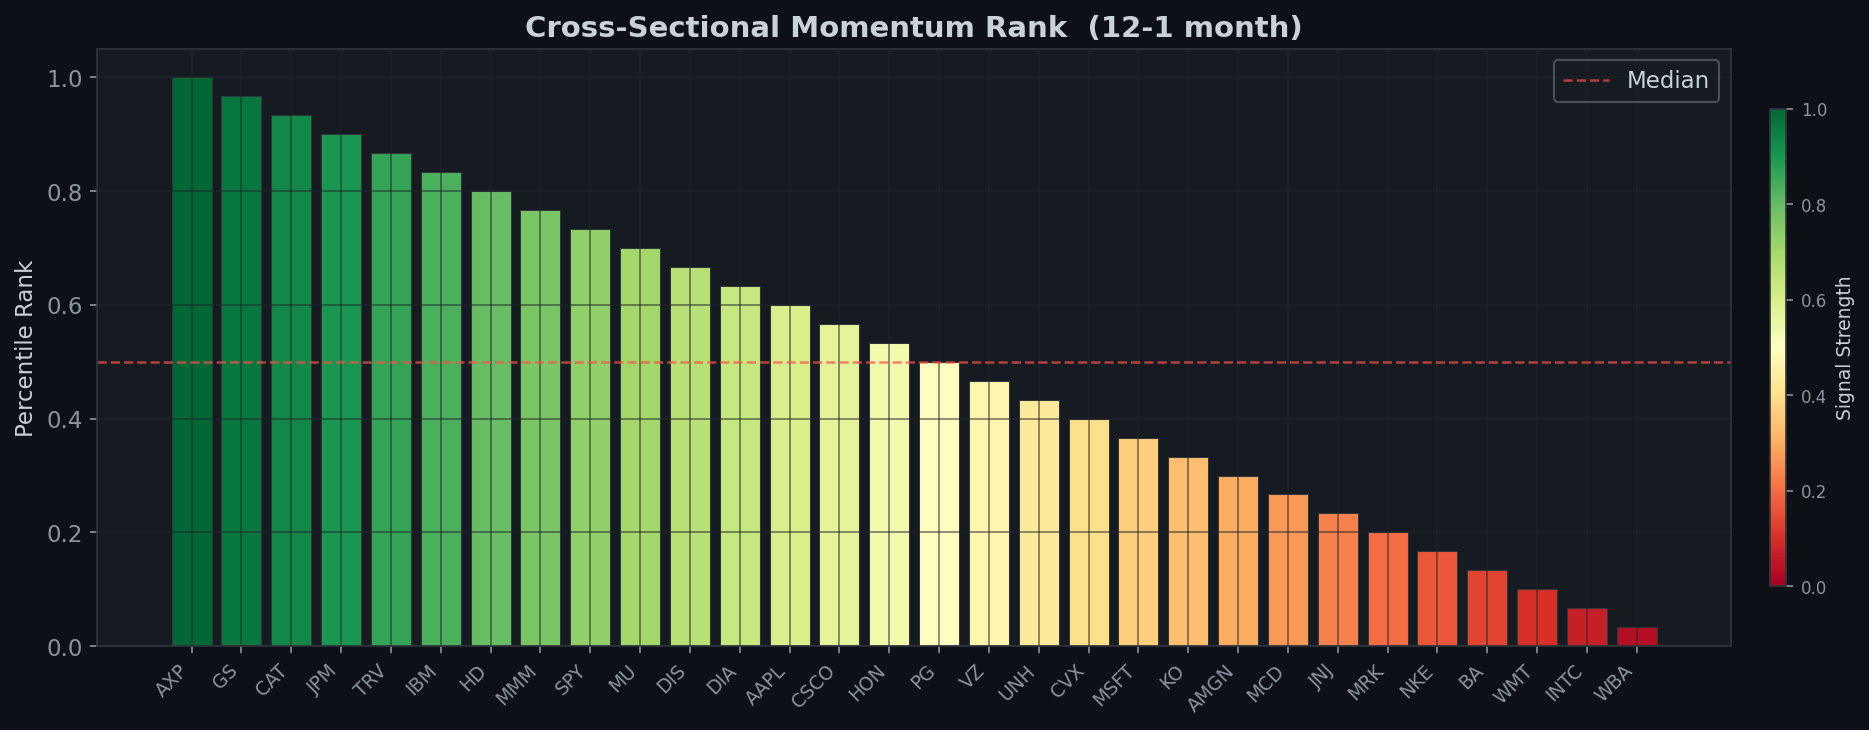

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# Color bars by rank: red (weak) → green (strong)
cmap = mpl.colormaps['RdYlGn']
norm = mpl.colors.Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in latest.values]

bars = ax.bar(range(len(latest)), latest.values, color=colors,
              edgecolor='#30363d', linewidth=0.5, width=0.8)

ax.axhline(0.5, color='#f85149', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Median')

ax.set_xticks(range(len(latest)))
ax.set_xticklabels(latest.index, rotation=45, ha='right', fontsize=9)
ax.set_title("Cross-Sectional Momentum Rank  (12-1 month)")
ax.set_ylabel("Percentile Rank")
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', framealpha=0.3)

# Add a subtle colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30, shrink=0.8)
cbar.set_label('Signal Strength', fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

## Next Steps

- Add more signals: value (P/B), quality (ROE), low-vol
- Build a simple long/short portfolio and compute IC
- Export signal scores to ObjectStore for use in QC backtests